In [1]:
#Rice leaf prediction using CNN

In [2]:
##problem Statement
'''
Rice is one of the most important food crops worldwide. Diseases such as Bacterial Leaf Blight, Brown Spot, and Leaf Smut can significantly reduce crop yield.
Early detection of these diseases helps farmers take timely preventive measures.

This project develops a Convolutional Neural Network (CNN) model to automatically classify rice leaf images into three disease categories using deep learning techniques. 
The project includes dataset visualization, preprocessing, model training, evaluation, prediction, and performance analysis.'''

'\nRice is one of the most important food crops worldwide. Diseases such as Bacterial Leaf Blight, Brown Spot, and Leaf Smut can significantly reduce crop yield.\nEarly detection of these diseases helps farmers take timely preventive measures.\n\nThis project develops a Convolutional Neural Network (CNN) model to automatically classify rice leaf images into three disease categories using deep learning techniques. \nThe project includes dataset visualization, preprocessing, model training, evaluation, prediction, and performance analysis.'

In [3]:
#importing libraries
import os
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
#data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#image processing
import cv2

In [6]:
#import tensorflow and keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [7]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
#model evaluation
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
#display settings
plt.style.use('ggplot')
%matplotlib inline

In [10]:
#dataset path
dataset_path = r'C:\Users\vmahi1206\Downloads\PRCP-1001-RiceLeaf\Data'

In [11]:
#dataset Info
classes = os.listdir(dataset_path)
print('class names:')
print(classes)
print('\n Total Classes:', len(classes))

class names:
['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

 Total Classes: 3


In [12]:
#EDA
image_count = {}
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)
    image_count[cls] = len(images) 
image_count

{'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

In [13]:
print('No of images in each cell:')
for disease, count in image_count.items():
    print(f'{disease}:{count}')

No of images in each cell:
Bacterial leaf blight:40
Brown spot:40
Leaf smut:40


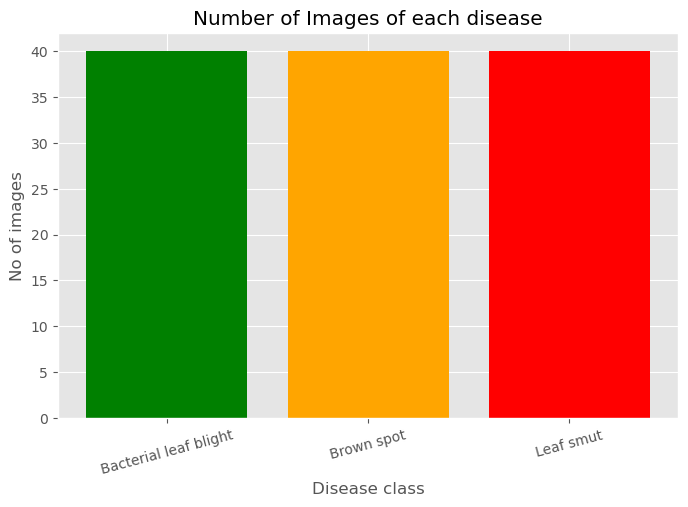

In [14]:
#visualize
plt.figure(figsize=(8, 5))
plt.bar(image_count.keys(), image_count.values(), color = ['green', 'orange', 'red'])
plt.title('Number of Images of each disease')
plt.xlabel('Disease class')
plt.ylabel('No of images')
plt.xticks(rotation = 15)
plt.show()

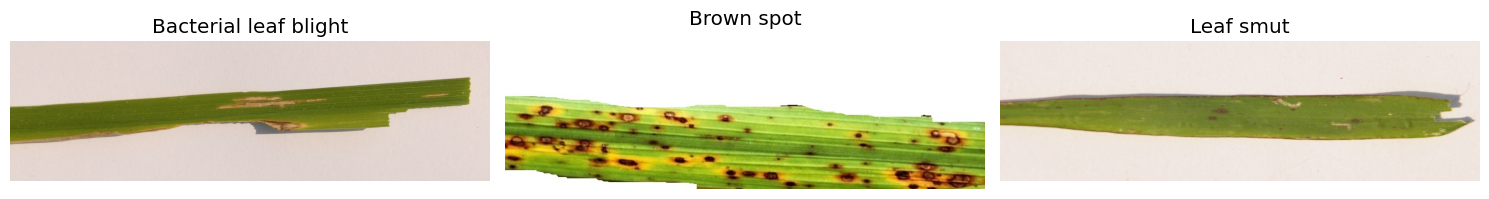

In [15]:
plt.figure(figsize=(15,5))
for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(classes), i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
class_path = os.path.join(dataset_path, classes[0])
image_name = os.listdir(class_path)[0]
image_path = os.path.join(class_path, image_name)
print("Image Path:", image_path)
img = cv2.imread(image_path)
print("Image Object:", img)
if img is not None:
    print("Image Shape:", img.shape)
else:
    print("OpenCV could not read the image.")

Image Path: C:\Users\vmahi1206\Downloads\PRCP-1001-RiceLeaf\Data\Bacterial leaf blight\DSC_0365.JPG
Image Object: [[[209 214 229]
  [209 214 229]
  [210 215 230]
  ...
  [211 215 226]
  [211 215 226]
  [212 216 227]]

 [[209 214 229]
  [209 214 229]
  [210 215 230]
  ...
  [211 215 226]
  [210 214 225]
  [212 216 227]]

 [[209 214 229]
  [209 214 229]
  [209 214 229]
  ...
  [210 216 227]
  [209 215 226]
  [210 216 227]]

 ...

 [[212 215 230]
  [211 214 229]
  [211 214 229]
  ...
  [207 213 226]
  [207 213 226]
  [208 214 225]]

 [[213 216 231]
  [212 215 230]
  [211 214 229]
  ...
  [208 214 227]
  [208 214 227]
  [209 215 226]]

 [[211 215 233]
  [211 215 233]
  [210 214 232]
  ...
  [210 214 225]
  [209 213 224]
  [206 212 223]]]
Image Shape: (897, 3081, 3)


In [17]:
#analyzing image dimensions
image_heights = []
image_widths = []
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, c = img.shape
            image_heights.append(h)
            image_widths.append(w)
print("Total Images:", len(image_heights))
print("\nMinimum Height :", min(image_heights))
print("Maximum Height :", max(image_heights))
print("\nMinimum Width :", min(image_widths))
print("Maximum Width :", max(image_widths))

Total Images: 120

Minimum Height : 71
Maximum Height : 900

Minimum Width : 250
Maximum Width : 3081


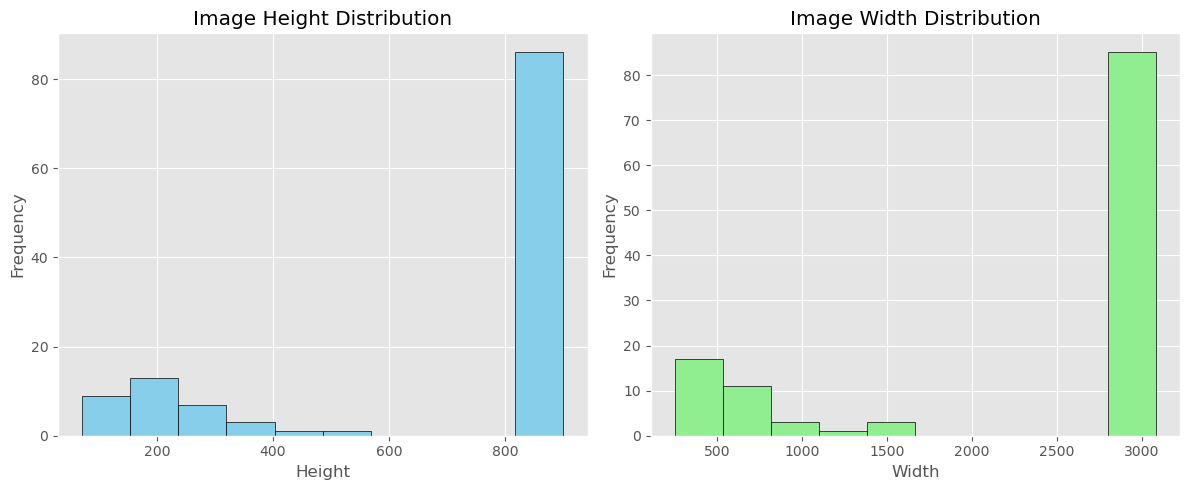

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(image_heights, bins=10, color="skyblue", edgecolor="black")
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(image_widths, bins=10, color="lightgreen", edgecolor="black")
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [19]:
#image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    shear_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

In [20]:
#Training dataset
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 96 images belonging to 3 classes.


In [21]:
#Validation dataset
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 24 images belonging to 3 classes.


In [22]:
print("Training Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)
print("\nClass Indices:")
print(train_generator.class_indices)

Training Images : 96
Validation Images : 24

Class Indices:
{'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


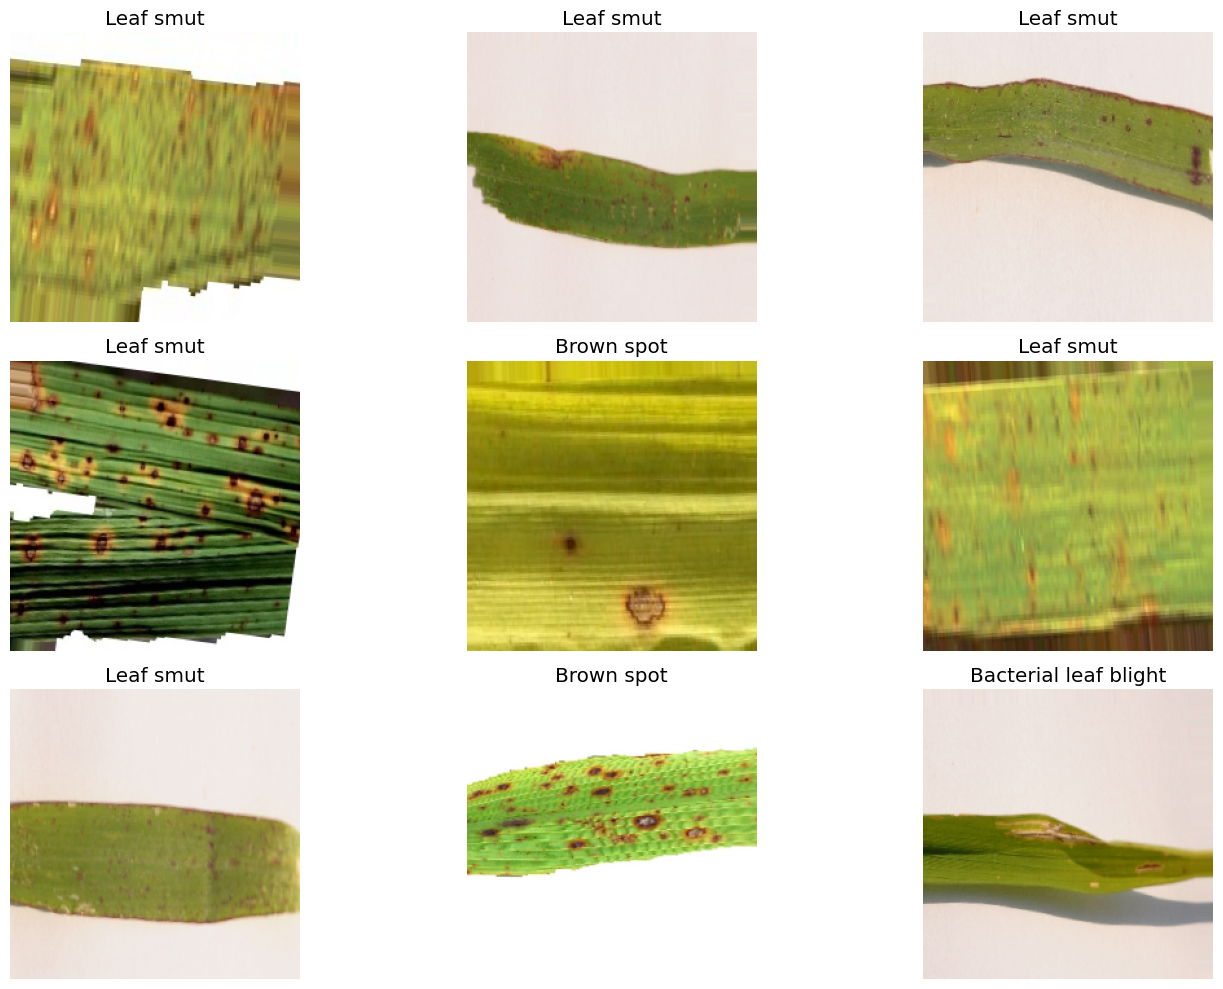

In [23]:
#visualize data augmentation
images, labels = next(train_generator)
plt.figure(figsize=(15,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    predicted_class = list(train_generator.class_indices.keys())[np.argmax(labels[i])]
    plt.title(predicted_class)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [24]:
### Data Augmentation Analysis
'''
Since the dataset contains only 120 images, there is a high risk of overfitting.
To improve the model's ability to generalize, data augmentation was applied using ImageDataGenerator.
The following augmentation techniques were used:
- Rotation
- Zoom
- Horizontal Flip
- Width Shift
- Height Shift
- Shear Transformation
These transformations increase the diversity of the training dataset without collecting additional images, helping the CNN learn robust disease-related features.
'''

"\nSince the dataset contains only 120 images, there is a high risk of overfitting.\nTo improve the model's ability to generalize, data augmentation was applied using ImageDataGenerator.\nThe following augmentation techniques were used:\n- Rotation\n- Zoom\n- Horizontal Flip\n- Width Shift\n- Height Shift\n- Shear Transformation\nThese transformations increase the diversity of the training dataset without collecting additional images, helping the CNN learn robust disease-related features.\n"

In [25]:
#Building CNN Model
model = Sequential([
    
    # First Convolution Block
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),    
    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu'
),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    # Convert Feature Maps to 1D
    GlobalAveragePooling2D(),
    
    # Fully Connected Layer
    Dense(128, activation='relu'),
    
    # Prevent Overfitting
    Dropout(0.4),
    
    # Output Layer
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
#compile model
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [27]:
checkpoint = ModelCheckpoint(
    "best_rice_leaf_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=16,
    restore_best_weights=True
)

In [28]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.3646 - loss: 1.1551 - val_accuracy: 0.5417 - val_loss: 1.0968
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.5312 - loss: 0.9579 - val_accuracy: 0.5000 - val_loss: 1.0964
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6250 - loss: 0.8717 - val_accuracy: 0.5417 - val_loss: 1.0960
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6042 - loss: 0.8644 - val_accuracy: 0.5417 - val_loss: 1.0957
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6771 - loss: 0.7962 - val_accuracy: 0.4583 - val_loss: 1.0953
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.7083 - loss: 0.7618 - val_accuracy: 0.4167 - val_loss: 1.0951
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6875 - loss: 0.7778 - val_accuracy: 0.4167 - val_loss: 1.0950
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7604 - loss: 0.7202 - val_accuracy: 0.4167 - val_loss: 1.0948
Epoch 9/

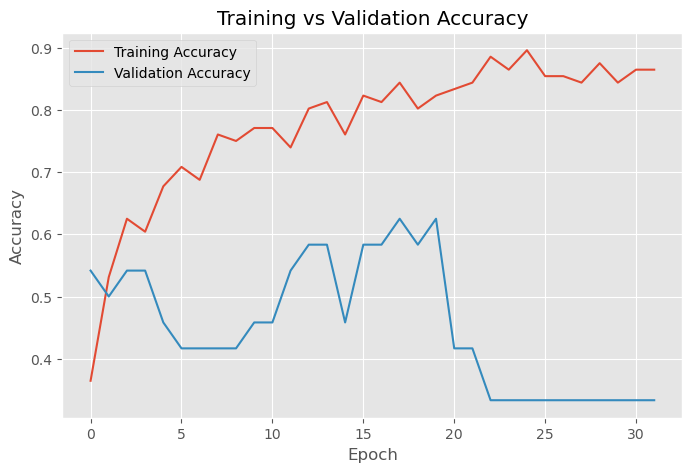

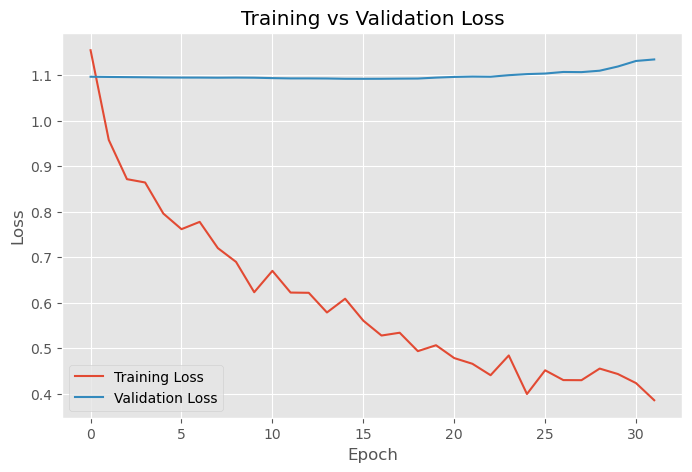

In [29]:
# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [30]:
#Model Evaluation
loss, accuracy = model.evaluate(validation_generator)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 978ms/step - accuracy: 0.6250 - loss: 1.0926

Validation Loss: 1.0926
Validation Accuracy: 0.6250
Validation Accuracy: 62.50%


In [31]:
### Model Evaluation
'''
The trained CNN model was evaluated using the validation dataset.

The evaluation returned the validation loss and validation accuracy, which indicate how well the model generalizes to unseen images. 
Since the dataset contains only 120 images, fluctuations in validation accuracy are expected due to the limited amount of training data.
'''

'\nThe trained CNN model was evaluated using the validation dataset.\n\nThe evaluation returned the validation loss and validation accuracy, which indicate how well the model generalizes to unseen images. \nSince the dataset contains only 120 images, fluctuations in validation accuracy are expected due to the limited amount of training data.\n'

In [32]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 24 images belonging to 3 classes.


In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Reset validation generator
validation_generator.reset()

# Predict on validation set
predictions = model.predict(
    validation_generator,
    verbose=0
)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# Get true class labels
true_classes = validation_generator.classes

# Get class names
class_names = list(validation_generator.class_indices.keys())

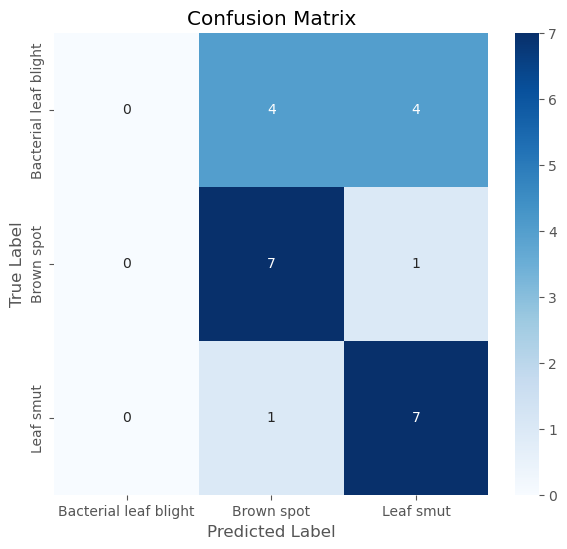

In [34]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [35]:
print("Classification Report\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

Classification Report

                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00         8
           Brown spot       0.58      0.88      0.70         8
            Leaf smut       0.58      0.88      0.70         8

             accuracy                           0.58        24
            macro avg       0.39      0.58      0.47        24
         weighted avg       0.39      0.58      0.47        24



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step


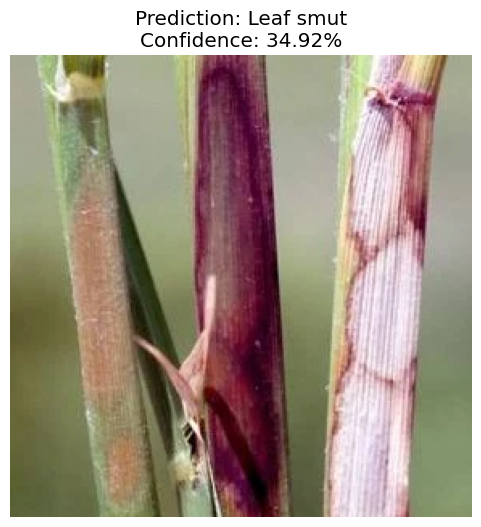

In [36]:
# Predict Disease for a New Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path of the test image
image_path = r"C:\Users\vmahi1206\Downloads\PRCP-1001-RiceLeaf\Data\Leaf smut\DSC_0521.jpg"      # Replace with your image path

# Read image
img = cv2.imread(image_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
img_resized = cv2.resize(img_rgb, (224, 224))

# Normalize pixel values
img_normalized = img_resized / 255.0

# Add batch dimension
input_image = np.expand_dims(img_normalized, axis=0)

# Predict
prediction = model.predict(input_image)

# Predicted class
predicted_class = np.argmax(prediction)

# Confidence score
confidence = np.max(prediction)

# Class names
class_names = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

# Display image
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Prediction: {class_names[predicted_class]}\nConfidence: {confidence:.2%}")
plt.show()

In [37]:
# Model Performance Summary
'''
The Convolutional Neural Network (CNN) was developed to classify rice leaf diseases into three categories:

- Bacterial Leaf Blight
- Brown Spot
- Leaf Smut

The model was trained using resized images (224 × 224 pixels) with data augmentation techniques such as rotation, zooming, shearing, shifting, and horizontal flipping. These techniques helped increase the diversity of the training dataset and reduced overfitting.

The model was evaluated using validation accuracy, validation loss, confusion matrix, and classification report. These evaluation metrics provide insight into the model's ability to classify unseen rice leaf images.

---

# Challenges Faced

During the development of this project, the following challenges were encountered:

1. The dataset contained only 120 images, which is relatively small for training a deep learning model.

2. Limited training data resulted in fluctuations in validation accuracy and reduced the model's ability to generalize.

3. Some disease classes have visually similar symptoms, making classification more challenging.

4. The CNN architecture contains a large number of trainable parameters compared to the dataset size, increasing the risk of overfitting.

---

# Future Improvements

The performance of the model can be improved by:

- Collecting a larger and more diverse rice leaf disease dataset.
- Applying additional preprocessing techniques such as background removal and image enhancement.
- Using Transfer Learning models such as MobileNetV2, ResNet50, EfficientNet, or VGG16.
- Performing hyperparameter tuning for learning rate, batch size, and optimizer.
- Training for more epochs using a larger dataset.

---

# Conclusion

This project successfully demonstrates the use of Convolutional Neural Networks (CNNs) for rice leaf disease classification. 
The workflow included dataset exploration, preprocessing, data augmentation, CNN model development, training, evaluation, and prediction on unseen images.

Although the model performance is limited by the small dataset size, the project illustrates the complete deep learning pipeline for image classification. 
With additional data and more advanced deep learning architectures, the model can achieve significantly better accuracy and become suitable for practical agricultural disease detection systems.
'''

"\nThe Convolutional Neural Network (CNN) was developed to classify rice leaf diseases into three categories:\n\n- Bacterial Leaf Blight\n- Brown Spot\n- Leaf Smut\n\nThe model was trained using resized images (224 × 224 pixels) with data augmentation techniques such as rotation, zooming, shearing, shifting, and horizontal flipping. These techniques helped increase the diversity of the training dataset and reduced overfitting.\n\nThe model was evaluated using validation accuracy, validation loss, confusion matrix, and classification report. These evaluation metrics provide insight into the model's ability to classify unseen rice leaf images.\n\n---\n\n# Challenges Faced\n\nDuring the development of this project, the following challenges were encountered:\n\n1. The dataset contained only 120 images, which is relatively small for training a deep learning model.\n\n2. Limited training data resulted in fluctuations in validation accuracy and reduced the model's ability to generalize.\n\n3.

In [38]:
print(history.history.keys())
print(history.history['accuracy'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
[0.3645833432674408, 0.53125, 0.625, 0.6041666865348816, 0.6770833134651184, 0.7083333134651184, 0.6875, 0.7604166865348816, 0.75, 0.7708333134651184, 0.7708333134651184, 0.7395833134651184, 0.8020833134651184, 0.8125, 0.7604166865348816, 0.8229166865348816, 0.8125, 0.84375, 0.8020833134651184, 0.8229166865348816, 0.8333333134651184, 0.84375, 0.8854166865348816, 0.8645833134651184, 0.8958333134651184, 0.8541666865348816, 0.8541666865348816, 0.84375, 0.875, 0.84375, 0.8645833134651184, 0.8645833134651184]


In [39]:
ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [40]:
import os

for cls in sorted(os.listdir(dataset_path)):
    p = os.path.join(dataset_path, cls)
    if os.path.isdir(p):
        print(cls, len(os.listdir(p)))

Bacterial leaf blight 40
Brown spot 40
Leaf smut 40


In [41]:
from tensorflow.keras.models import load_model
model = load_model("best_rice_leaf_model.keras")